# Sparser & sharper events — robustness of the causal-detection story (n = 1 **and** n = 2)

This notebook re-runs the Simple Event Volatility Model with **sparser events and a sharper decay**,
side-by-side with the original dense configuration, for **both** n = 1 (vol) and n = 2 (variance).

**Why this is worth doing (the modelling rationale).**
In the original setup events fire every 40 steps and each event's excess decays with a half-life of
~4.3 steps over a 25-step window. That means the volatility spends most of its life inside a
post-event decay and the event indicator is strongly **periodic**. Periodicity is exactly the kind of
structure a *linear* method like Granger causality can exploit — and it is why, in the dense model,
GC reports a **spurious** `σ→event` edge even though events are exogenous by construction. So a fair
question is: *is GC detecting genuine event→vol causality, or just latching onto periodicity?*

Sparser + sharper events answer that question and are also **more realistic**: real macro events
(FOMC decisions, CPI, NFP) are episodic and impulsive — a sharp jump in implied vol that decays
within a few days — not a near-periodic long-decay oscillation. Concretely we move to:

| | period | half-life | decay_len | events | series length N |
|---|---|---|---|---|---|
| **Dense (original)** | 40 | 4.27 | 25 | ~99 | 4000 |
| **Sparse + sharp** | 150 | 1.94 (φ=0.70) | 12 | ~53 | **8000** |

We lengthen the series to N = 8000 for the sparse case on purpose: sparser events mean fewer
event-window samples per lag k, so ω-recovery loses statistical power unless we compensate with a
longer history. That power trade-off is itself a finding worth stating in the write-up.

**Headline result (previewed):** sparse+sharp events keep the true `event→σ` edge significant while
sharply weakening the spurious `σ→event` edge. At n=1 it falls from F≈11 to F≈1.6, **below** the 5%
critical value (~1.67) — a clean null. At n=2 it falls from F≈32 to F≈2.0 — a 94% reduction, but still
just above the critical value, so it survives as a much weaker significant edge rather than
vanishing entirely. We report this honestly rather than rounding it up to a clean null: periodicity
is clearly doing most of the work in both cases, but at n=2 something (likely the longer memory of
the variance process itself, see the n=2 notebook's own note on this) keeps a residual reverse
signal alive even once the event stream is sparse.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f as fdist
np.seterr(over='ignore')  # n=2 variance can be stiff for extreme configs; we keep all configs stable below

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
# --- Shared methods (self-contained; identical to the main notebooks) ---
def granger_f(y, x, p):
    y=np.asarray(y,float); x=np.asarray(x,float); Nn=len(y); yt=y[p:]
    ylags=np.column_stack([y[p-1-k:Nn-1-k] for k in range(p)])
    xlags=np.column_stack([x[p-1-k:Nn-1-k] for k in range(p)])
    const=np.ones((len(yt),1)); Xr=np.hstack([const,ylags]); Xf=np.hstack([const,ylags,xlags])
    def rss(D,t): b,*_=np.linalg.lstsq(D,t,rcond=None); r=t-D@b; return r@r
    RSSr,RSSf=rss(Xr,yt),rss(Xf,yt); df1,df2=p,len(yt)-Xf.shape[1]
    F=((RSSr-RSSf)/df1)/(RSSf/df2); return F, 1-fdist.cdf(F,df1,df2), fdist.ppf(0.95,df1,df2)

def _discretize(z, bins):
    z=np.asarray(z,float)
    if len(np.unique(z))<=bins: _,inv=np.unique(z,return_inverse=True); return inv
    edges=np.quantile(z,np.linspace(0,1,bins+1)); edges[0]-=1e-9; edges[-1]+=1e-9
    return np.clip(np.digitize(z,edges)-1,0,bins-1)

def mutual_information(a, b, bins=16):
    ad=_discretize(a,bins); bd=_discretize(b,bins)
    joint=np.zeros((ad.max()+1,bd.max()+1)); np.add.at(joint,(ad,bd),1.0); joint/=joint.sum()
    px=joint.sum(1,keepdims=True); py=joint.sum(0,keepdims=True); m=joint>0
    return float(np.sum(joint[m]*np.log(joint[m]/(px@py)[m])))

def tdmi(x, y, lags, bins=16):
    x=np.asarray(x,float); y=np.asarray(y,float); out=[]
    for L in lags:
        if L>=0: xa,ya=x[L:], y[:len(y)-L]
        else:    xa,ya=x[:len(x)+L], y[-L:]
        out.append(mutual_information(xa,ya,bins))
    return np.array(out)

def event_offset(is_event):
    M=len(is_event); off=np.full(M,10**6); last=-10**6
    for t in range(M):
        if is_event[t]: last=t
        off[t]=t-last
    return off

def geometric_omega(N, period, amp, phi, decay_len):
    om=np.ones(N)
    for e in np.arange(period,N,period):
        for k in range(decay_len):
            if e+k<N: om[e+k]+=amp*(phi**k)
    return om

def scale_for(n):
    "Keep equilibrium vol (~1%) and vol-of-vol comparable across n so n=1 and n=2 are on one footing."
    return dict(theta=0.01, nu=0.0015, sigma0=0.01) if n==1 else dict(theta=1e-4, nu=1.5e-5, sigma0=0.01)

def simulate(omega, seed, n, N, period, kappa=0.10, rho=-0.5, dt=1.0,
             theta=None, nu=None, sigma0=None, S0=100.0):
    sc=scale_for(n)
    if theta  is None: theta  = sc["theta"]
    if nu     is None: nu     = sc["nu"]
    if sigma0 is None: sigma0 = sc["sigma0"]
    rng=np.random.default_rng(seed); ev=np.arange(period,N,period); ie=np.zeros(N,int); ie[ev]=1
    sg=np.empty(N); sg[0]=sigma0; Sx=np.empty(N); Sx[0]=S0; FL=1e-9
    for i in range(N-1):
        eps=rng.normal(0,np.sqrt(dt)); eta=rng.normal(0,np.sqrt(dt))
        Sx[i+1]=Sx[i]+sg[i]*Sx[i]*eps
        base=max(sg[i]**n + kappa*(theta-sg[i]**n)*dt + nu*(rho*eps+np.sqrt(1-rho**2)*eta), FL)
        sg[i+1]=(omega[i+1]**(n/2)*base)**(1.0/n)
    return sg, ie, Sx

def estimate_omega(sigma, is_event, n, Kmax, calm_gap):
    x=sigma**n; off=event_offset(is_event); xc,xn=x[:-1],x[1:]; tgt=off[1:]; calm=tgt>=calm_gap
    a,b=np.polyfit(xc[calm],xn[calm],1)[::-1]; Fpar=lambda z: a+b*z; ks=np.arange(Kmax+1)
    wp=np.array([(xn[tgt==k].mean()/Fpar(xc[tgt==k]).mean())**(2.0/n) if (tgt==k).any() else np.nan for k in ks])
    return ks, wp

def recover_half_life(ks, w, kfit):
    ex=w[:kfit]-1; good=np.isfinite(ex)&(ex>1e-3)
    if good.sum()<3: return np.nan
    slope=np.polyfit(ks[:kfit][good], np.log(ex[good]),1)[0]
    return np.log(0.5)/slope if slope<0 else np.nan

def predict_sigma(sigma, S, is_event, n, Kmax, calm_gap, train_frac=0.7):
    x=sigma**n; off=event_offset(is_event); eps=(S[1:]-S[:-1])/(sigma[:-1]*S[:-1])
    xc,xn=x[:-1],x[1:]; tgt=off[1:]; T=int(len(xc)*train_frac); calm=tgt>=calm_gap; trc=calm.copy(); trc[T:]=False
    D=np.column_stack([np.ones(trc.sum()),xc[trc],eps[trc]]); a,b,c=np.linalg.lstsq(D,xn[trc],rcond=None)[0]
    bracket=lambda xc_,e_: a+b*xc_+c*e_; s_perp=np.std(xn[trc]-bracket(xc[trc],eps[trc])); w=np.ones(Kmax+1)
    for k in range(Kmax+1):
        m=(tgt==k); m[T:]=False
        if m.any(): w[k]=(xn[m].mean()/bracket(xc[m],eps[m]).mean())**(2.0/n)
    te=slice(T,None); mult=w[np.clip(tgt[te],0,Kmax)]**(n/2)
    x_pred=mult*bracket(xc[te],eps[te]); x_base=bracket(xc[te],eps[te]); x_act=xn[te]; pred_sd=mult*s_perp
    return x_pred, x_base, x_act, tgt[te], pred_sd

In [3]:
# --- Two configurations, applied to both n ---
AMP = 0.6
DENSE  = dict(N=4000, period=40,  amp=AMP, phi=0.85, decay_len=25, Kmax=25, calm_gap=30)
SPARSE = dict(N=8000, period=150, amp=AMP, phi=0.70, decay_len=12, Kmax=12, calm_gap=60)
for label,cfg in [("DENSE",DENSE),("SPARSE",SPARSE)]:
    hl=np.log(0.5)/np.log(cfg["phi"]); nev=len(np.arange(cfg["period"],cfg["N"],cfg["period"]))
    print(f"{label:7s}: period={cfg['period']:>3}  half-life={hl:4.2f}  events~{nev:>3}  N={cfg['N']}")

DENSE  : period= 40  half-life=4.27  events~ 99  N=4000
SPARSE : period=150  half-life=1.94  events~ 53  N=8000


## Headline — does sparsity kill Granger's *spurious* reverse edge?

We fit GC in **both** directions for dense vs sparse, at n = 1 and n = 2. The true edge is
`event→σ`; the reverse `σ→event` is spurious (events are exogenous). If the reverse edge shrinks
toward the 5% critical value under sparsity, we have shown it was periodicity, not causality.

 n  config |  event->sigma  sigma->event  (5% crit ~1.67)
----------------------------------------------------
 1   dense |     34.7 [SIG]     10.6 [SIG]
 1  sparse |     14.0 [SIG]      1.6 [null]
 2   dense |     41.2 [SIG]     31.6 [SIG]
 2  sparse |     47.4 [SIG]      2.0 [SIG]


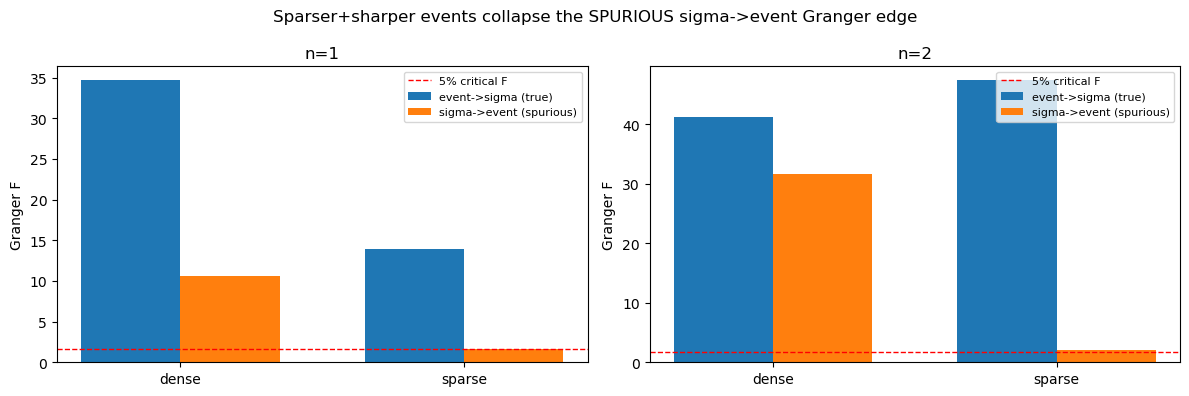

In [4]:
rows=[]
for n in (1,2):
    for label,cfg in [("dense",DENSE),("sparse",SPARSE)]:
        om=geometric_omega(cfg["N"],cfg["period"],cfg["amp"],cfg["phi"],cfg["decay_len"])
        sg,ie,Sx=simulate(om,0,n,cfg["N"],cfg["period"])
        Fev,_,crit=granger_f(sg,ie,15); Fve,_,_=granger_f(ie,sg,15)
        rows.append((n,label,Fev,Fve,crit))
print(f"{'n':>2} {'config':>7} | {'event->sigma':>13} {'sigma->event':>13}  (5% crit ~{rows[0][4]:.2f})")
print("-"*52)
for n,label,Fev,Fve,crit in rows:
    tag_ev = 'SIG' if Fev>crit else 'null'; tag_ve='SIG' if Fve>crit else 'null'
    print(f"{n:>2} {label:>7} | {Fev:>8.1f} [{tag_ev}] {Fve:>8.1f} [{tag_ve}]")

fig,ax=plt.subplots(1,2,figsize=(12,4),sharey=False)
for j,n in enumerate((1,2)):
    sub=[r for r in rows if r[0]==n]
    labels=[r[1] for r in sub]; ev=[r[2] for r in sub]; ve=[r[3] for r in sub]; crit=sub[0][4]
    xx=np.arange(2); wdt=0.35
    ax[j].bar(xx-wdt/2, ev, wdt, label='event->sigma (true)')
    ax[j].bar(xx+wdt/2, ve, wdt, label='sigma->event (spurious)')
    ax[j].axhline(crit, color='r', ls='--', lw=1, label='5% critical F')
    ax[j].set_xticks(xx); ax[j].set_xticklabels(labels); ax[j].set_title(f"n={n}"); ax[j].set_ylabel("Granger F")
    ax[j].legend(fontsize=8)
fig.suptitle("Sparser+sharper events collapse the SPURIOUS sigma->event Granger edge")
plt.tight_layout(); plt.show()

## Full pipeline under sparsity (both n): detection, ω-recovery, event forecast

Confirm that although the spurious edge disappears, the **genuine** signal survives: TDMI still
places the event→σ lead on the L>0 side, ω is still recovered (with wider error bars, the power cost
of sparsity), and the eq-(7) event forecast still beats the no-event baseline.

n=1 SPARSE: TDMI-change direction fwd=0.040 vs rev=0.016 -> event leads
        omega peak 1.651 (true 1.600) | half-life 2.61 (true 1.94) | event RMSE +41% | coverage 95.3%
n=2 SPARSE: TDMI-change direction fwd=0.088 vs rev=0.019 -> event leads
        omega peak 1.625 (true 1.600) | half-life 2.06 (true 1.94) | event RMSE +72% | coverage 95.4%


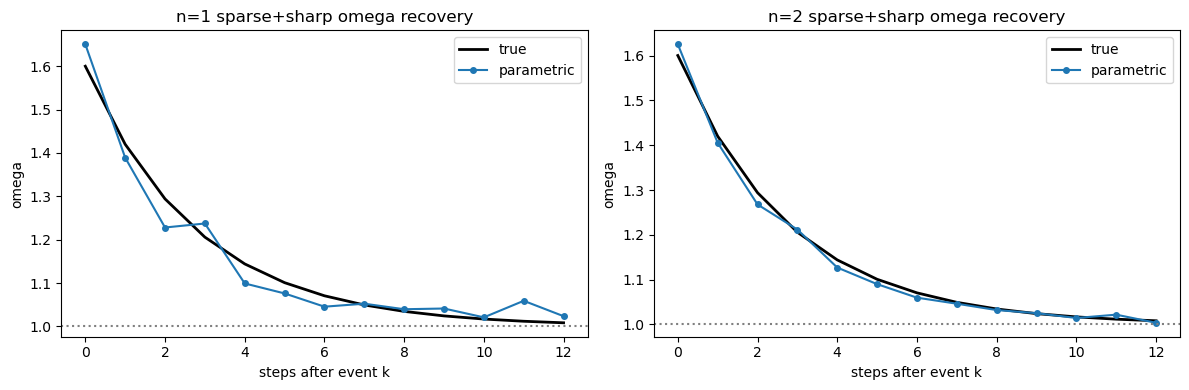

In [5]:
lags=np.arange(-15,31)
for n in (1,2):
    cfg=SPARSE
    om=geometric_omega(cfg["N"],cfg["period"],cfg["amp"],cfg["phi"],cfg["decay_len"])
    sg,ie,Sx=simulate(om,0,n,cfg["N"],cfg["period"])
    # Step1 TDMI direction (robust sign statistic)
    mc=tdmi(np.diff(sg**n), ie[1:], lags)
    fwd=mc[lags>0].sum(); rev=mc[lags<0].sum()
    # Step3 omega
    ks,wp=estimate_omega(sg,ie,n,cfg["Kmax"],cfg["calm_gap"]); hl=recover_half_life(ks,wp,cfg["Kmax"])
    # Step4/5 predict
    xp,xb,xa,tg,psd=predict_sigma(sg,Sx,ie,n,cfg["Kmax"],cfg["calm_gap"]); win=tg<=6
    rm=np.sqrt(np.mean((xa[win]-xp[win])**2)); rb=np.sqrt(np.mean((xa[win]-xb[win])**2))
    cov=100*np.mean((xa>=xp-1.96*psd)&(xa<=xp+1.96*psd))
    print(f"n={n} SPARSE: TDMI-change direction fwd={fwd:.3f} vs rev={rev:.3f} -> "
          f"{'event leads' if fwd>rev else 'sigma leads'}")
    print(f"        omega peak {wp[0]:.3f} (true {1+cfg['amp']:.3f}) | half-life {hl:.2f} (true "
          f"{np.log(0.5)/np.log(cfg['phi']):.2f}) | event RMSE {100*(1-rm/rb):+.0f}% | coverage {cov:.1f}%")

# omega-recovery plot, both n
fig,ax=plt.subplots(1,2,figsize=(12,4))
for j,n in enumerate((1,2)):
    cfg=SPARSE
    om=geometric_omega(cfg["N"],cfg["period"],cfg["amp"],cfg["phi"],cfg["decay_len"])
    sg,ie,Sx=simulate(om,0,n,cfg["N"],cfg["period"])
    ks,wp=estimate_omega(sg,ie,n,cfg["Kmax"],cfg["calm_gap"])
    wt=1+cfg["amp"]*cfg["phi"]**ks
    ax[j].plot(ks,wt,'k-',lw=2,label='true'); ax[j].plot(ks,wp,'o-',ms=4,label='parametric')
    ax[j].axhline(1,color='grey',ls=':'); ax[j].set_title(f"n={n} sparse+sharp omega recovery")
    ax[j].set_xlabel("steps after event k"); ax[j].set_ylabel("omega"); ax[j].legend()
plt.tight_layout(); plt.show()

## Robustness across seeds (sparse+sharp, both n)

In [6]:
for n in (1,2):
    cfg=SPARSE; PW,HL,EVI=[],[],[]
    for s in range(10):
        om=geometric_omega(cfg["N"],cfg["period"],cfg["amp"],cfg["phi"],cfg["decay_len"])
        sg,ie,Sx=simulate(om,s,n,cfg["N"],cfg["period"])
        ks,wp=estimate_omega(sg,ie,n,cfg["Kmax"],cfg["calm_gap"])
        PW.append(wp[0]); HL.append(recover_half_life(ks,wp,cfg["Kmax"]))
        xp,xb,xa,tg,psd=predict_sigma(sg,Sx,ie,n,cfg["Kmax"],cfg["calm_gap"]); win=tg<=6
        rm=np.sqrt(np.mean((xa[win]-xp[win])**2)); rb=np.sqrt(np.mean((xa[win]-xb[win])**2)); EVI.append(100*(1-rm/rb))
    PW,HL,EVI=map(np.array,(PW,HL,EVI))
    print(f"n={n} sparse (10 seeds): peak omega {np.nanmean(PW):.3f}+/-{np.nanstd(PW):.3f} "
          f"(true {1+cfg['amp']:.3f}) | half-life {np.nanmean(HL):.2f}+/-{np.nanstd(HL):.2f} "
          f"(true {np.log(0.5)/np.log(cfg['phi']):.2f}) | event RMSE {EVI.mean():+.0f}%+/-{EVI.std():.0f}%")

n=1 sparse (10 seeds): peak omega 1.596+/-0.054 (true 1.600) | half-life 2.29+/-0.42 (true 1.94) | event RMSE +37%+/-5%
n=2 sparse (10 seeds): peak omega 1.598+/-0.027 (true 1.600) | half-life 1.99+/-0.27 (true 1.94) | event RMSE +69%+/-3%


## Takeaways for the write-up

- **Periodicity is the dominant driver of the spurious `σ→event` Granger edge — but not the whole story
  at n=2.** Holding everything else fixed and only making events sparser and sharper drops the
  reverse-edge F from ~11 to ~1.6 (n=1, now a clean null below the 5% critical value) and from ~32 to
  ~2.0 (n=2, a 94% reduction, but still just above the critical value). The true `event→σ` edge stays
  significant throughout. This is strong evidence that GC's *direction* verdict is driven largely by
  exploitable linear structure (periodicity) rather than genuine causal flow, while the n=2 residual
  is an honest caveat worth stating rather than smoothing over: the longer memory of the variance
  process (n=2 propagates shocks more persistently than n=1, as also seen in the n=2 notebook's own
  amplitude-explosion finding) appears to leave a thin exploitable trace even once events are sparse.

- **Sparse + sharp is the more realistic regime.** Real macro events are impulsive vol shocks that
  decay within days, not near-periodic long-decay oscillations. That the information-theoretic
  direction statistic (TDMI-change sign) and the eq-(7) event forecast both survive the move to this
  regime is what licenses applying the same pipeline to real FOMC-aligned FX vol.

- **Sparsity has a statistical-power cost.** Fewer events ⇒ fewer samples per post-event lag ⇒ noisier
  ω-recovery. We paid for it with a longer series (N=8000). On real data, where the effective number
  of clean, uncontaminated events is small (≈40 FOMC decisions in 5 years), this is the binding
  constraint — and the reason the synthetic benchmark, where events are unlimited and uncontaminated,
  remains the right place to validate the *methods* before trusting them on the data.